# Exploratory Data Analysis — Belgian DAM & Imbalance Prices

**Datasets**
- **DAM** (`dataset/dam/`): hourly Belgian day-ahead prices + covariates, Dec 2020 – Jan 2025  
- **IMB** (`dataset/imb/`): 15-min Belgian imbalance prices + reserve market data, Jan 2021 – Dec 2023

**Contents**
1. [Day-Ahead Market (DAM)](#dam)  
   1.1 Descriptive statistics  
   1.2 Weekly percentiles with event annotations *(Chart 1)*  
   1.3 Hourly × weekday heatmap  
   1.4 Price distribution  
   1.5 Cross-correlation matrix *(Chart 2)*  
   1.6 Lagged cross-correlation with covariates  
   1.7 ACF / PACF  
2. [Imbalance Price (IMB)](#imb)  
   2.1 Descriptive statistics  
   2.2 Weekly percentiles with event annotations *(Chart 1)*  
   2.3 Quarter-hour × weekday heatmap  
   2.4 Price distribution  
   2.5 Cross-correlation matrix *(Chart 2)*  
   2.6 Lagged cross-correlation with covariates  
   2.7 System Imbalance distribution  
3. [Joint Analysis](#joint)  
   3.1 DAM vs IMB price scatter  
   3.2 Extreme event frequency by year  

All charts are exported to `eda_figures/`.

In [2]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not found — pip install statsmodels")

try:
    import kaleido  # noqa: F401
    CAN_EXPORT = True
except ImportError:
    CAN_EXPORT = False
    print("kaleido not found — pip install kaleido")

# ── Global style ─────────────────────────────────────────────────────────
TEMPLATE   = "plotly_white"
FONT       = "Arial"
EXPORT_DIR = "eda_figures"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Maps exported filename → chart title (populated by save / save_mpl)
FIGURE_REGISTRY: dict[str, str] = {}

C_BLUE, C_RED, C_GREEN, C_ORANGE = "#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sns.set_theme(style="whitegrid", font_scale=1.1)


def save(fig, name, title="", w=1200, h=480):
    """Export a Plotly figure and register its title."""
    if title:
        FIGURE_REGISTRY[name] = title
    path = os.path.join(EXPORT_DIR, name)
    if CAN_EXPORT:
        fig.write_image(path, width=w, height=h, scale=2)
        print(f"Saved → {path}")


def save_mpl(name, title=""):
    """Export a Matplotlib figure and register its title."""
    if title:
        FIGURE_REGISTRY[name] = title
    path = os.path.join(EXPORT_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")


print(f"Export directory: {os.path.abspath(EXPORT_DIR)}")

Export directory: /Users/maichi/KULeuven/Y2/thesis/implementation/tsfm-dam-imb-price-forecasting/notebooks/eda_figures


In [9]:
# ── Data loading ──────────────────────────────────────────────────────────────
def load_concat(train_path, test_path, ts_col):
    df = pd.concat([
        pd.read_csv(train_path),
        pd.read_csv(test_path),
    ], ignore_index=True)
    ts = pd.to_datetime(df[ts_col])
    df[ts_col] = ts.dt.tz_convert(None) if ts.dt.tz is not None else ts
    return df.sort_values(ts_col).reset_index(drop=True)


dam = load_concat("../dataset/dam/data_train.csv", "../dataset/dam/data_test.csv", "Date")
imb = load_concat("../dataset/imb/data_train.csv", "../dataset/imb/data_test.csv", "timestamp")

dam = dam[dam['Date']>=pd.Timestamp(2021,1,1)]
dam = dam[dam['Date']<pd.Timestamp(2025,1,1)]
# ── Temporal features ─────────────────────────────────────────────────────────
dam["week"]  = dam["Date"].dt.to_period("W").dt.start_time
dam["month"] = dam["Date"].dt.to_period("M").dt.start_time
dam["hour"]  = dam["Date"].dt.hour
dam["dow"]   = dam["Date"].dt.day_name()
dam["year"]  = dam["Date"].dt.year

imb["week"]  = imb["timestamp"].dt.to_period("W").dt.start_time
imb["hour"]  = imb["timestamp"].dt.hour
imb["qh"]    = imb["timestamp"].dt.minute // 15 + 1   # 1-4
imb["dow"]   = imb["timestamp"].dt.day_name()
imb["year"]  = imb["timestamp"].dt.year

print(f"DAM : {len(dam):,} rows | {dam.Date.min().date()} → {dam.Date.max().date()}")
print(f"IMB : {len(imb):,} rows | {imb.timestamp.min().date()} → {imb.timestamp.max().date()}")

DAM : 35,064 rows | 2021-01-01 → 2024-12-31
IMB : 105,120 rows | 2021-01-01 → 2023-12-31


In [4]:
from utils import load_dataset

ModuleNotFoundError: No module named 'utils'

In [ ]:
test_data = load_dataset("../dataset/imb/data_test.csv", "timestamp")

In [ ]:
test_data.describe().T

---
## 1 — Day-Ahead Market (DAM) <a id='dam'></a>

In [10]:
# 1.1 — Descriptive statistics
cols_dam = ["Price", "Load", "Solar", "Wind", "Temp", "Hum"]
stats = dam[cols_dam].describe().T
stats.insert(0, "missing%", dam[cols_dam].isna().mean() * 100)
stats.round(2)

,missing%,count,mean,std,min,25%,50%,75%,max
Price,0.0,35064.0,129.02,108.17,-140.00,63.71,97.18,164.20,871.0
Load,0.0,35064.0,9339.95,1293.31,6091.50,8327.44,9342.38,10260.81,13245.0
Solar,0.0,35064.0,756.20,1236.07,0.00,0.00,20.00,1111.00,7264.0
Wind,0.0,35064.0,1530.30,1228.28,4.00,429.75,1207.00,2492.00,4628.0
Temp,0.0,35064.0,11.60,6.77,-8.25,6.80,11.35,16.45,37.0
Hum,0.0,35064.0,79.12,14.70,20.26,69.79,83.01,90.90,100.0


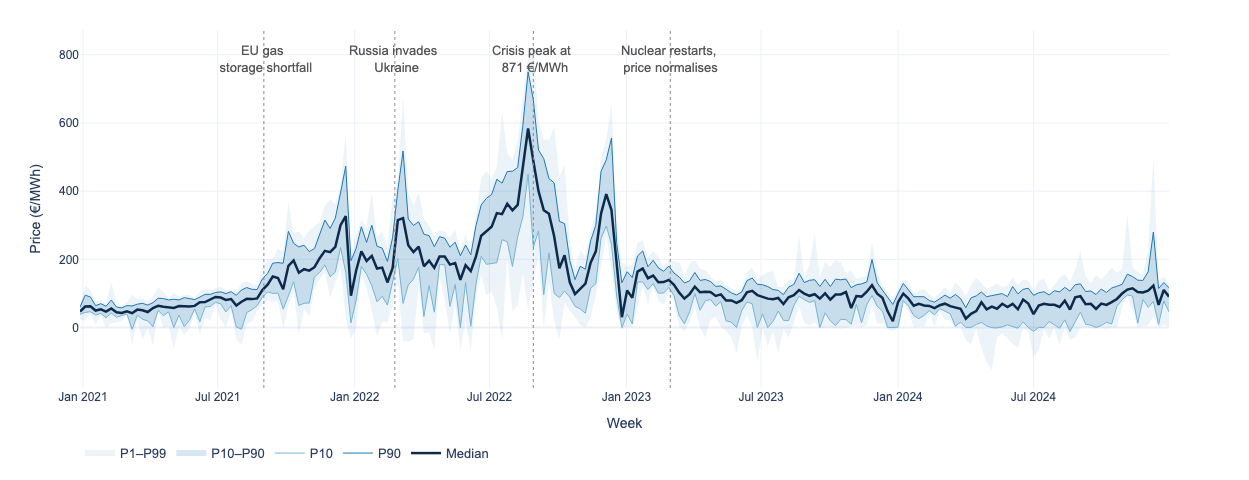

In [20]:
# 1.2 — Weekly percentiles with event annotations (Chart 1)
PCTS = [1, 10, 50, 90, 99]

def weekly_pct(df, col, pcts=PCTS):
    return (
        df.groupby("week")[col]
        .quantile([p / 100 for p in pcts])
        .unstack(-1)
        .rename(columns={p / 100: f"p{p}" for p in pcts})
        .reset_index()
    )

wp = weekly_pct(dam, "Price")

DAM_EVENTS = [
    dict(date="2021-09-01", label="EU gas <br> storage shortfall",          top=True),
    # dict(date="2022-01-17", label="Gas price record<br>(pre-invasion)",   top=False),
    dict(date="2022-02-24", label="Russia invades <br> Ukraine",            top=True),
    # dict(date="2022-07-01", label="Belgian nuclear<br>fleet offline",     top=False),
    dict(date="2022-08-29", label="Crisis peak at <br> 871 €/MWh",             top=True),
    # dict(date="2022-12-01", label="EU gas storage<br>full ",     top=False),
    dict(date="2023-03-01", label="Nuclear restarts, <br>price normalises", top=True),
]

_TITLE_DAM_WP = "Belgian Day-Ahead Price — Weekly Percentiles (2020–2025)"

fig = go.Figure()

for lo, hi, alpha, name in [
    ("p1",  "p99", 0.08, "P1–P99"),
    ("p10", "p90", 0.18, "P10–P90"),
]:
    x = list(wp.week) + list(wp.week[::-1])
    y = list(wp[hi])  + list(wp[lo][::-1])
    fig.add_trace(go.Scatter(
        x=x, y=y, fill="toself", mode="none",
        fillcolor=f"rgba(31,119,180,{alpha})",
        name=name, showlegend=True,
    ))

for col, lw, color, name in [
    ("p10", 1.0, "#74b4d4", "P10"),
    ("p90", 1.0, "#1f77b4", "P90"),
    ("p50", 2.5, "#0d2a4a", "Median"),
]:
    fig.add_trace(go.Scatter(
        x=wp.week, y=wp[col], mode="lines",
        line=dict(width=lw, color=color), name=name,
    ))

# Annotations centred over each vline — no bounding box
for ev in DAM_EVENTS:
    dt      = pd.Timestamp(ev["date"])
    ypos    = 0.97 if ev["top"] else 0.03
    yanchor = "top" if ev["top"] else "bottom"
    fig.add_vline(x=dt, line=dict(color="#888", dash="dot", width=1))
    fig.add_annotation(
        x=dt, y=ypos, yref="paper",
        text=ev["label"],
        showarrow=False, xanchor="center",
        font=dict(size=13, color="#555"),
        yanchor=yanchor,
    )

fig.update_layout(
    template=TEMPLATE, font_family=FONT,
    xaxis_title="Week", yaxis_title="Price (€/MWh)",
    legend=dict(orientation="h", y=-0.14, font=dict(size=13)),
    height=480, margin=dict(t=30, b=70),
    # scale = 20
)
# save(fig, "dam_weekly_percentiles.png", title=_TITLE_DAM_WP, h=500)
fig.show()

Saved → eda_figures/dam_hourly_heatmap.png


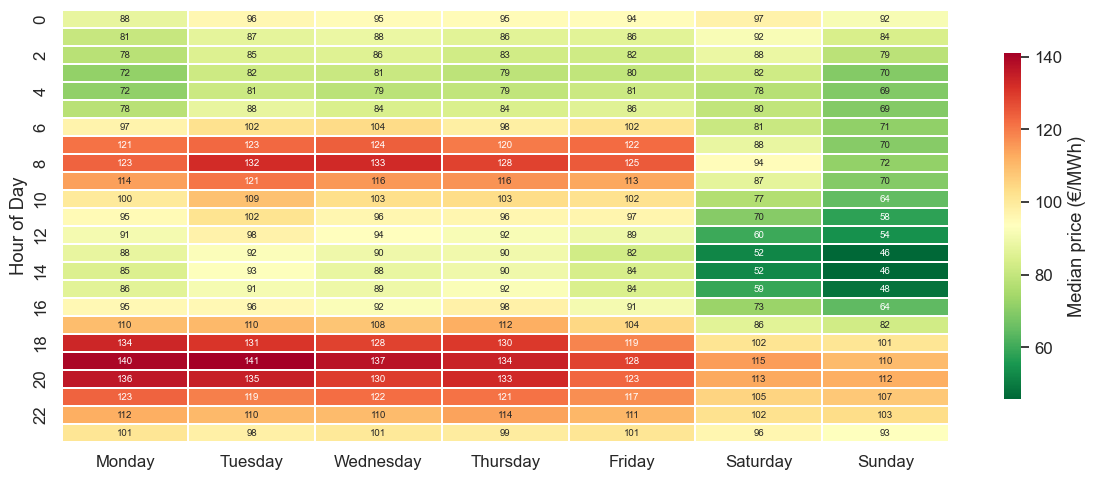

In [21]:
# 1.3 — Median price by hour × day of week
_TITLE_DAM_HH = "DAM Price — Median by Hour × Day of Week"

pivot = dam.pivot_table(
    index="hour", columns="dow", values="Price", aggfunc="median"
)[DOW_ORDER]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot, ax=ax,
    cmap="RdYlGn_r", fmt=".0f", annot=True, annot_kws={"size": 7},
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Median price (€/MWh)", "shrink": 0.8},
)
ax.set_xlabel(""); ax.set_ylabel("Hour of Day")
plt.tight_layout()
save_mpl("dam_hourly_heatmap.png", title=_TITLE_DAM_HH)
plt.show()

Saved → eda_figures/dam_distribution.png


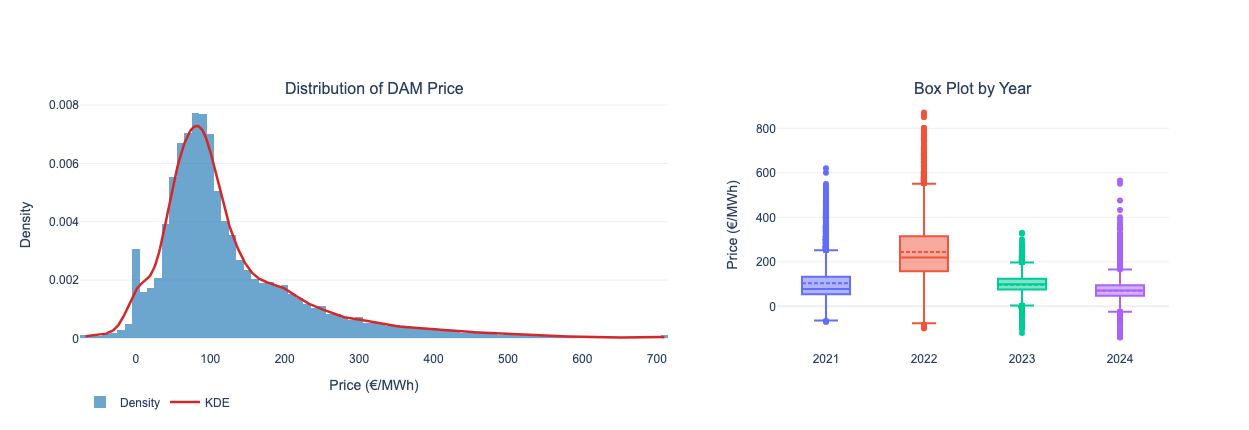

In [22]:
# 1.4 — Price distribution: histogram + KDE, and box per year
_TITLE_DAM_DIST = "DAM Price Distribution"

clip_lo, clip_hi = dam.Price.quantile(0.001), dam.Price.quantile(0.999)
prices_clipped   = dam.Price.clip(clip_lo, clip_hi)

kde_x = np.linspace(clip_lo, clip_hi, 600)
kde_y = gaussian_kde(prices_clipped.dropna())(kde_x)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Distribution of DAM Price", "Box Plot by Year"],
    column_widths=[0.6, 0.4],
)
fig.add_trace(go.Histogram(
    x=prices_clipped, nbinsx=120,
    marker_color=C_BLUE, opacity=0.65,
    histnorm="probability density", name="Density",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=kde_x, y=kde_y, mode="lines",
    line=dict(color=C_RED, width=2.5), name="KDE",
), row=1, col=1)

year_colors = px.colors.qualitative.Plotly
for k, yr in enumerate(sorted(dam.year.unique())):
    fig.add_trace(go.Box(
        y=dam[dam.year == yr].Price,
        name=str(yr), marker_color=year_colors[k % len(year_colors)],
        showlegend=False, boxmean=True,
    ), row=1, col=2)

fig.update_layout(
    template=TEMPLATE, font_family=FONT,
    height=430, showlegend=True,
    legend=dict(orientation="h", y=-0.15),
)
fig.update_xaxes(title_text="Price (€/MWh)", row=1, col=1)
fig.update_yaxes(title_text="Density",       row=1, col=1)
fig.update_yaxes(title_text="Price (€/MWh)", row=1, col=2)
save(fig, "dam_distribution.png", title=_TITLE_DAM_DIST, h=450)
fig.show()

Saved → eda_figures/dam_correlation_matrix.png


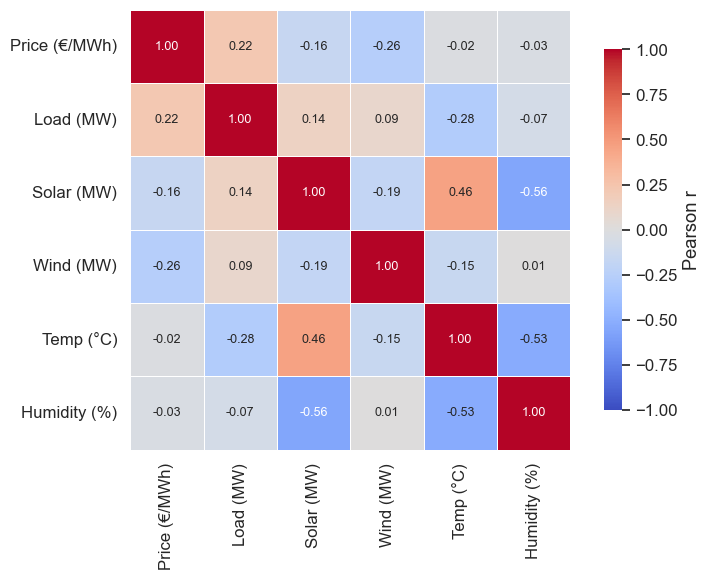

In [23]:
# 1.5 — Cross-correlation matrix (Chart 2)
_TITLE_DAM_CORR = "DAM — Pearson Correlation Matrix"

DAM_FEATS = ["Price", "Load", "Solar", "Wind", "Temp", "Hum"]
LABELS_DAM = {
    "Price": "Price (€/MWh)", "Load": "Load (MW)",
    "Solar": "Solar (MW)",     "Wind": "Wind (MW)",
    "Temp":  "Temp (°C)",      "Hum":  "Humidity (%)",
}
corr = dam[DAM_FEATS].corr().rename(columns=LABELS_DAM, index=LABELS_DAM)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, ax=ax,
    annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Pearson r", "shrink": 0.82},
    annot_kws={"size": 9},
)
plt.tight_layout()
save_mpl("dam_correlation_matrix.png", title=_TITLE_DAM_CORR)
plt.show()

Saved → eda_figures/dam_ccf_covariates.png


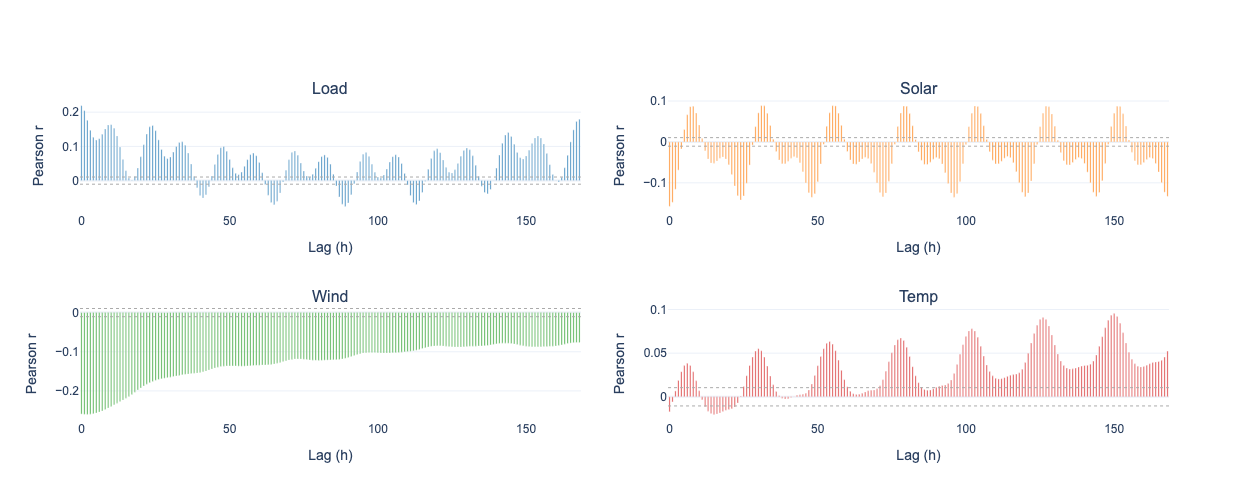

In [51]:
# 1.6 — Lagged cross-correlation: Price vs covariates (lags 0–48 h)
_TITLE_DAM_CCF = "DAM Price - Cross-Correlation with Covariates (7-day lag)"

MAX_LAG  = 168
COVARS   = ["Load", "Solar", "Wind", "Temp"]
COLORS   = [C_BLUE, C_ORANGE, C_GREEN, C_RED]
SIG_BAND = 1.96 / np.sqrt(len(dam))

lags = list(range(MAX_LAG + 1))
fig  = make_subplots(
    rows=2, cols=2, subplot_titles=COVARS,
    vertical_spacing=0.3, horizontal_spacing=0.08,
)

for idx, (cov, color) in enumerate(zip(COVARS, COLORS)):
    r, c = divmod(idx, 2)
    ccf  = [dam["Price"].corr(dam[cov].shift(lag)) for lag in lags]
    fig.add_trace(go.Bar(
        x=lags, y=ccf, marker_color=color, name=cov,
    ), row=r + 1, col=c + 1)
    for sign in [SIG_BAND, -SIG_BAND]:
        fig.add_hline(y=sign, line=dict(color="#aaa", dash="dot", width=1),
                      row=r + 1, col=c + 1)

fig.update_layout(
    template=TEMPLATE, font_family=FONT, showlegend=False,
    height=500,
)
fig['data'][0].width = 0.4
fig['data'][1].width = 0.4
fig['data'][2].width = 0.4
fig['data'][3].width = 0.4
fig.update_xaxes(title_text="Lag (h)")
fig.update_yaxes(title_text="Pearson r")
save(fig, "dam_ccf_covariates.png", title=_TITLE_DAM_CCF, h=520)
fig.show()

Saved → eda_figures/dam_acf_pacf.png


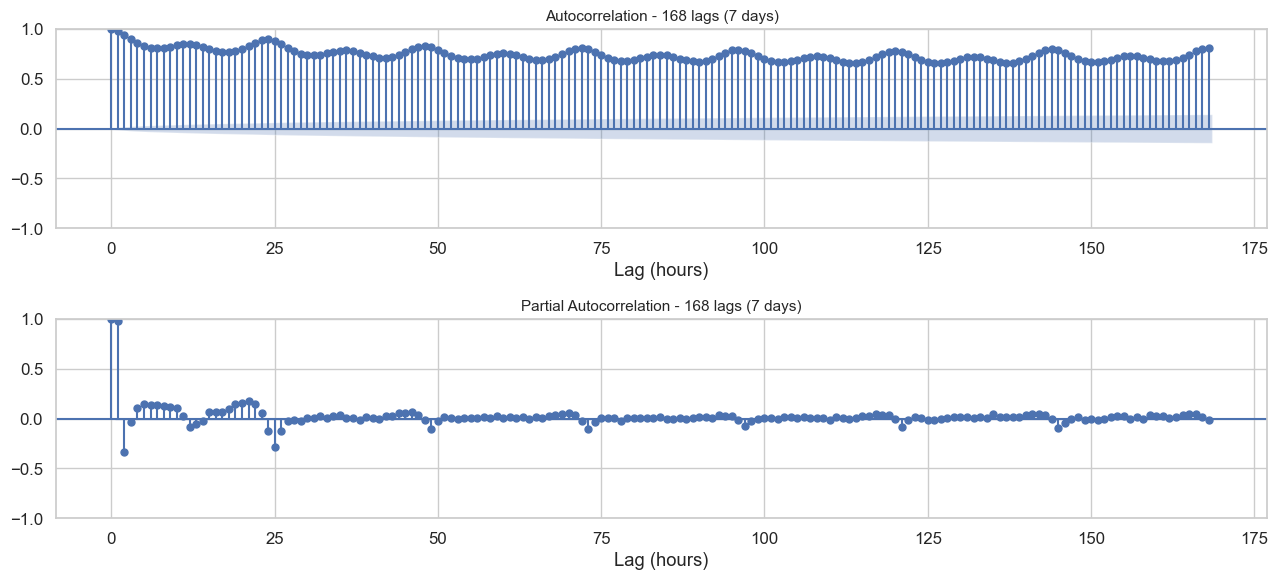

In [26]:
# 1.7 — ACF / PACF of DAM Price
_TITLE_DAM_ACF = "DAM Price — ACF (168 lags) and PACF (168 lags)"

if HAS_STATSMODELS:
    fig_mpl, axes = plt.subplots(2, 1, figsize=(13, 6))
    plot_acf(dam["Price"].dropna(),  lags=168, ax=axes[0], alpha=0.05)
    plot_pacf(dam["Price"].dropna(), lags=168,  ax=axes[1], alpha=0.05)
    axes[0].set_title("Autocorrelation - 168 lags (7 days)",        fontsize=11)
    axes[1].set_title("Partial Autocorrelation - 168 lags (7 days)", fontsize=11)
    for ax in axes:
        ax.set_xlabel("Lag (hours)")
    plt.tight_layout()
    save_mpl("dam_acf_pacf.png", title=_TITLE_DAM_ACF)
    plt.show()
else:
    print("Skipped — install statsmodels to see ACF/PACF.")

---
## 2 — Imbalance Price (IMB) <a id='imb'></a>

In [27]:
# 2.1 — Descriptive statistics
cols_imb = ["pos_ip", "da_price", "si"]
stats_imb = imb[cols_imb].describe().T
stats_imb.insert(0, "missing%", imb[cols_imb].isna().mean() * 100)
stats_imb.round(2)

,missing%,count,mean,std,min,25%,50%,75%,max
pos_ip,0.0,105120.0,143.55,181.63,-692.13,19.00,117.88,229.01,3455.72
da_price,0.0,105120.0,148.64,115.99,-120.00,73.08,112.82,196.34,871.00
si,0.0,105120.0,-28.45,174.05,-1419.71,-121.83,-22.14,67.84,1135.15


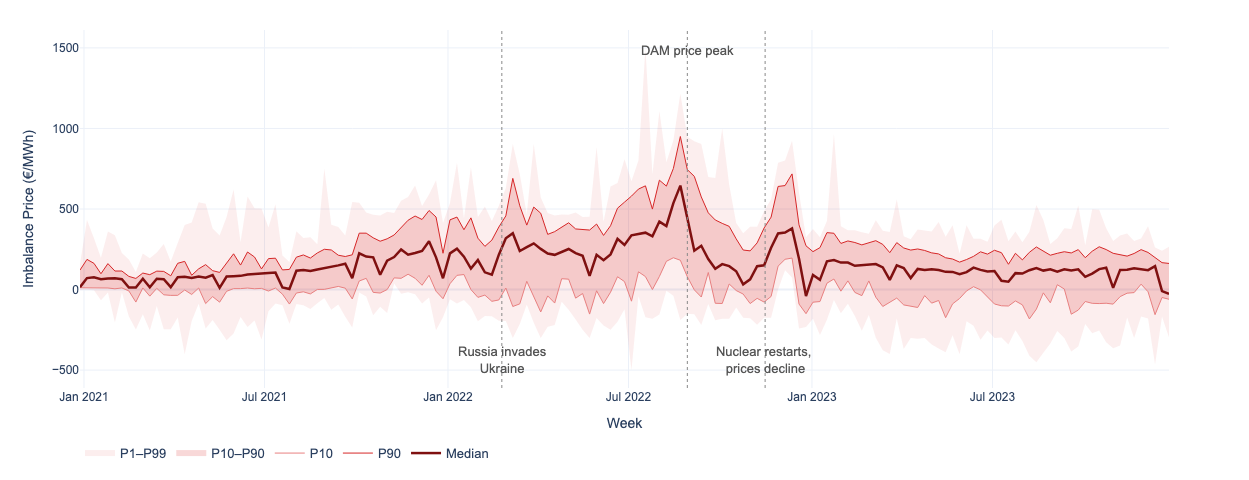

In [32]:
# 2.2 — Weekly percentiles with event annotations (Chart 1)
_TITLE_IMB_WP = "Belgian Imbalance Price — Weekly Percentiles (2021–2023)"

wp_imb = weekly_pct(imb, "pos_ip")

IMB_EVENTS = [
    # dict(date="2021-12-01", label="Belgian nuclear<br>outages begin",    top=True),
    dict(date="2022-02-24", label="Russia invades<br>Ukraine",           top=False),
    # dict(date="2022-07-01", label="Peak nuclear<br>unavailability",      top=True),
    dict(date="2022-08-29", label="DAM price peak",             top=True),
    dict(date="2022-11-15", label="Nuclear restarts, <br>prices decline",top=False),
    # dict(date="2023-04-01", label="Fleet recovery /<br>normalisation",   top=True),
]

fig = go.Figure()

for lo, hi, alpha, name in [
    ("p1",  "p99", 0.08, "P1–P99"),
    ("p10", "p90", 0.18, "P10–P90"),
]:
    x = list(wp_imb.week) + list(wp_imb.week[::-1])
    y = list(wp_imb[hi])  + list(wp_imb[lo][::-1])
    fig.add_trace(go.Scatter(
        x=x, y=y, fill="toself", mode="none",
        fillcolor=f"rgba(214,39,40,{alpha})",
        name=name, showlegend=True,
    ))

for col, lw, color, name in [
    ("p10", 1.0, "#e88080", "P10"),
    ("p90", 1.0, "#d62728", "P90"),
    ("p50", 2.5, "#7f1010", "Median"),
]:
    fig.add_trace(go.Scatter(
        x=wp_imb.week, y=wp_imb[col], mode="lines",
        line=dict(width=lw, color=color), name=name,
    ))

# Annotations centred over each vline — no bounding box
for ev in IMB_EVENTS:
    dt      = pd.Timestamp(ev["date"])
    ypos    = 0.97 if ev["top"] else 0.03
    yanchor = "top" if ev["top"] else "bottom"
    fig.add_vline(x=dt, line=dict(color="#888", dash="dot", width=1))
    fig.add_annotation(
        x=dt, y=ypos, yref="paper",
        text=ev["label"],
        showarrow=False, xanchor="center",
        font=dict(size=13, color="#555"),
        yanchor=yanchor,
    )

fig.update_layout(
    template=TEMPLATE, font_family=FONT,
    xaxis_title="Week", yaxis_title="Imbalance Price (€/MWh)",
    legend=dict(orientation="h", y=-0.14,font=dict(size=13)),
    height=480, margin=dict(t=30, b=70),
)
# save(fig, "imb_weekly_percentiles.png", title=_TITLE_IMB_WP, h=480)
fig.show()

Saved → eda_figures/imb_hourly_heatmap.png


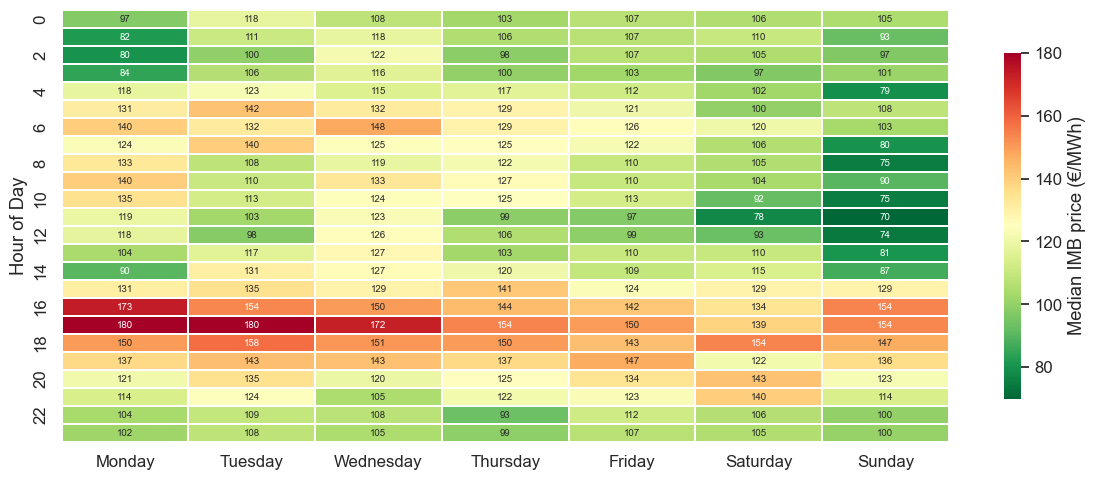

In [82]:
_TITLE_IMB_HH = "IMB Price — Median by Hour × Day of Week"

pivot = imb.pivot_table(
    index="hour", columns="dow", values="pos_ip", aggfunc="median"
)[DOW_ORDER]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot, ax=ax,
    cmap="RdYlGn_r", fmt=".0f", annot=True, annot_kws={"size": 7},
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Median IMB price (€/MWh)", "shrink": 0.8},
)
ax.set_xlabel(""); ax.set_ylabel("Hour of Day")
plt.tight_layout()
save_mpl("imb_hourly_heatmap.png", title=_TITLE_IMB_HH)
plt.show()

Saved → eda_figures/imb_qh_heatmap.png


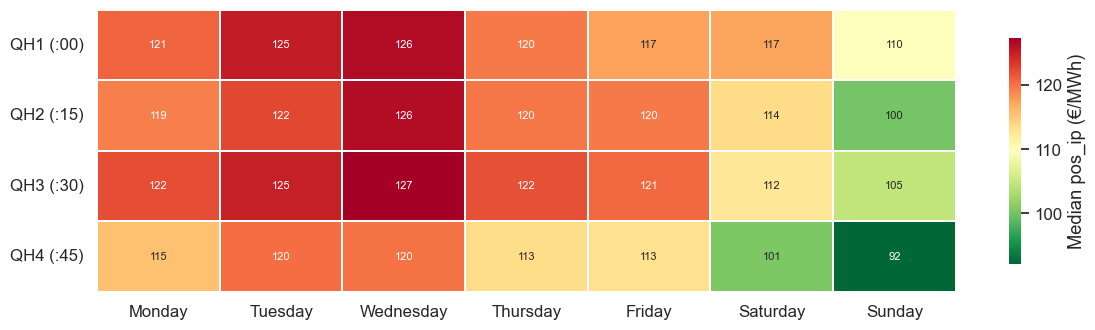

In [34]:
# 2.3 — Median IMB price by quarter-hour × day of week
_TITLE_IMB_QH = "IMB Price — Median by Quarter-Hour × Day of Week"

QH_LABELS = {1: "QH1 (:00)", 2: "QH2 (:15)", 3: "QH3 (:30)", 4: "QH4 (:45)"}
imb["qh_label"] = imb["qh"].map(QH_LABELS)

pivot_imb = imb.pivot_table(
    index="qh_label", columns="dow", values="pos_ip", aggfunc="median"
).reindex(list(QH_LABELS.values()))[DOW_ORDER]

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(
    pivot_imb, ax=ax,
    cmap="RdYlGn_r", fmt=".0f", annot=True, annot_kws={"size": 8},
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Median pos_ip (€/MWh)", "shrink": 0.8},
)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
save_mpl("imb_qh_heatmap.png", title=_TITLE_IMB_QH)
plt.show()

In [54]:
imb['year'] = imb.timestamp.dt.year

Saved → eda_figures/imb_distribution.png


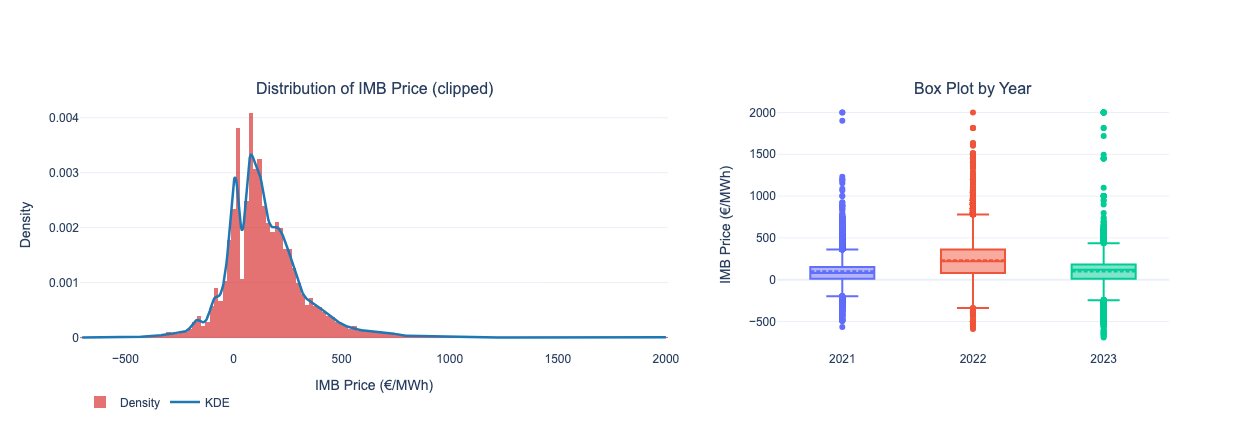

In [61]:
# 2.4 — IMB price distribution: histogram + KDE, and box per QH
_TITLE_IMB_DIST = "IMB Price Distribution"

CLIP_IMB = (-700, 2000)
ip_clip  = imb.pos_ip.clip(*CLIP_IMB)

kde_xi = np.linspace(*CLIP_IMB, 600)
kde_yi = gaussian_kde(ip_clip.dropna())(kde_xi)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Distribution of IMB Price (clipped)", "Box Plot by Year"],
    column_widths=[0.6, 0.4],
)
fig.add_trace(go.Histogram(
    x=ip_clip, nbinsx=150,
    marker_color=C_RED, opacity=0.65,
    histnorm="probability density", name="Density",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=kde_xi, y=kde_yi, mode="lines",
    line=dict(color=C_BLUE, width=2.5), name="KDE",
), row=1, col=1)

qh_colors = px.colors.qualitative.Plotly
for q in [2021,2022,2023]:
    fig.add_trace(go.Box(
        y=imb[imb.year == q].pos_ip.clip(*CLIP_IMB),
        name=q, marker_color=qh_colors[q - 2021],
        showlegend=False, boxmean=True,
    ), row=1, col=2)

fig.update_layout(
    template=TEMPLATE, font_family=FONT,
    height=430, showlegend=True,
    legend=dict(orientation="h", y=-0.15),
)
fig.update_xaxes(title_text="IMB Price (€/MWh)", row=1, col=1)
fig.update_yaxes(title_text="Density",         row=1, col=1)
fig.update_yaxes(title_text="IMB Price (€/MWh)",  row=1, col=2)
save(fig, "imb_distribution.png", title=_TITLE_IMB_DIST, h=450)
fig.show()

Saved → eda_figures/imb_correlation_matrix.png


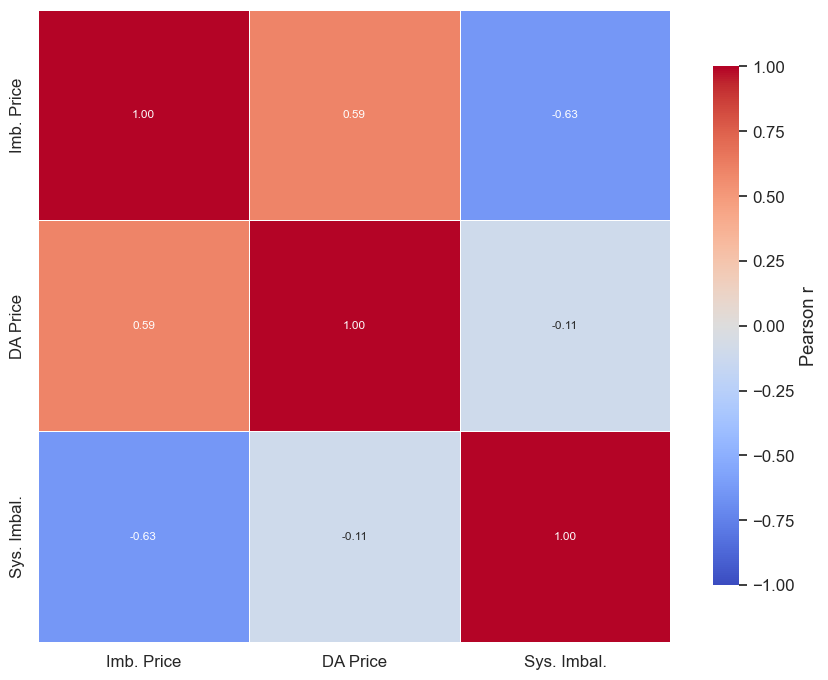

In [36]:
# 2.5 — Cross-correlation matrix (Chart 2)
_TITLE_IMB_CORR = "IMB — Pearson Correlation Matrix"

IMB_FEATS  = ["pos_ip", "da_price", "si"]
LABELS_IMB = {
    "pos_ip":       "Imb. Price",   "da_price":     "DA Price",
    "si":           "Sys. Imbal.",  "nrv":          "Net Reg. Vol.",
    "r2volumeup":   "aFRR Vol ↑",   "r2volumedown": "aFRR Vol ↓",
    "r3stdprice":   "mFRR Price",   "r3stdvolume":  "mFRR Vol",
}
corr_imb = (
    imb[IMB_FEATS].corr()
    .rename(columns=LABELS_IMB, index=LABELS_IMB)
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_imb, ax=ax,
    annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Pearson r", "shrink": 0.82},
    annot_kws={"size": 8.5},
)
plt.tight_layout()
save_mpl("imb_correlation_matrix.png", title=_TITLE_IMB_CORR)
plt.show()

Saved → eda_figures/imb_acf_pacf.png


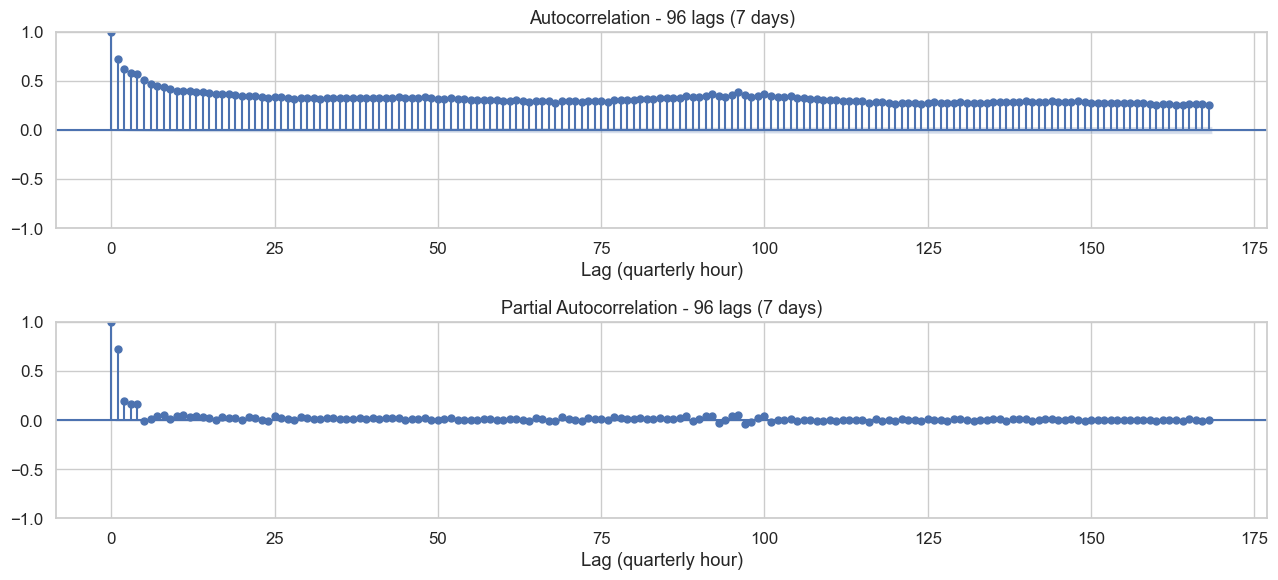

In [74]:
# 1.7 — ACF / PACF of DAM Price
_TITLE_IMB_ACF = "IMB Price — ACF (96 lags) and PACF (96 lags)"

# if HAS_STATSMODELS:
fig_mpl, axes = plt.subplots(2, 1, figsize=(13, 6))
plot_acf(imb["pos_ip"],  lags=168, ax=axes[0], alpha=0.05)
plot_pacf(imb["pos_ip"], lags=168,  ax=axes[1], alpha=0.05)
axes[0].set_title("Autocorrelation - 96 lags (7 days)",        fontsize=13)
axes[1].set_title("Partial Autocorrelation - 96 lags (7 days)", fontsize=13)
for ax in axes:
    ax.set_xlabel("Lag (quarterly hour)")
plt.tight_layout()
save_mpl("imb_acf_pacf.png", title=_TITLE_IMB_ACF)
plt.show()
# else:
#     print("Skipped — install statsmodels to see ACF/PACF.")

In [77]:
LABELS_IMB['si'] = "System imbalance"

Saved → eda_figures/imb_ccf_covariates.png


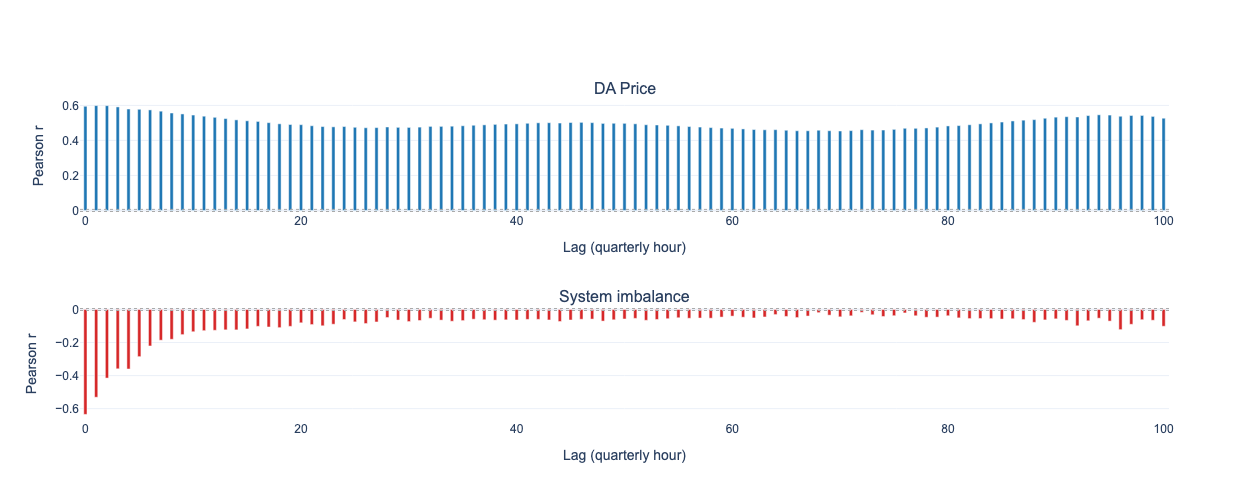

In [81]:
# 2.6 — Lagged cross-correlation: pos_ip vs covariates (lags 0–32 × 15 min = 8 h)
_TITLE_IMB_CCF = "IMB Price — Cross-Correlation with Covariates (lag = ×15 min)"

MAX_LAG_I  = 100
COVARS_IMB = ["da_price", "si",]
COLORS_IMB = [C_BLUE,  C_RED]#C_ORANGE, C_GREEN,
SIG_IMB    = 1.96 / np.sqrt(len(imb))

lags_i = list(range(MAX_LAG_I + 1))
fig    = make_subplots(
    rows=2, cols=1,
    subplot_titles=[LABELS_IMB.get(c, c) for c in COVARS_IMB],
    vertical_spacing=0.3, horizontal_spacing=0.1,
)
for idx, (cov, color) in enumerate(zip(COVARS_IMB, COLORS_IMB)):
    row = idx + 1          # row 1 for da_price, row 2 for si
    ccf = [imb["pos_ip"].corr(imb[cov].shift(lag)) for lag in lags_i]
    
    fig.add_trace(go.Bar(
        x=lags_i, y=ccf, marker_color=color, name=LABELS_IMB.get(cov, cov),
    ), row=row, col=1)      # ← explicit row/col here
    
    for sign in [SIG_IMB, -SIG_IMB]:
        fig.add_hline(y=sign, line=dict(color="#aaa", dash="dot", width=1),
                      row=row, col=1)
fig.update_layout(
    template=TEMPLATE, font_family=FONT, showlegend=False,
    height=500,
)
fig['data'][0].width = 0.3
fig['data'][1].width = 0.3

fig.update_xaxes(title_text="Lag (quarterly hour)")
fig.update_yaxes(title_text="Pearson r")
save(fig, "imb_ccf_covariates.png", title=_TITLE_IMB_CCF, h=520)
fig.show()

Saved → eda_figures/imb_si_distribution.png


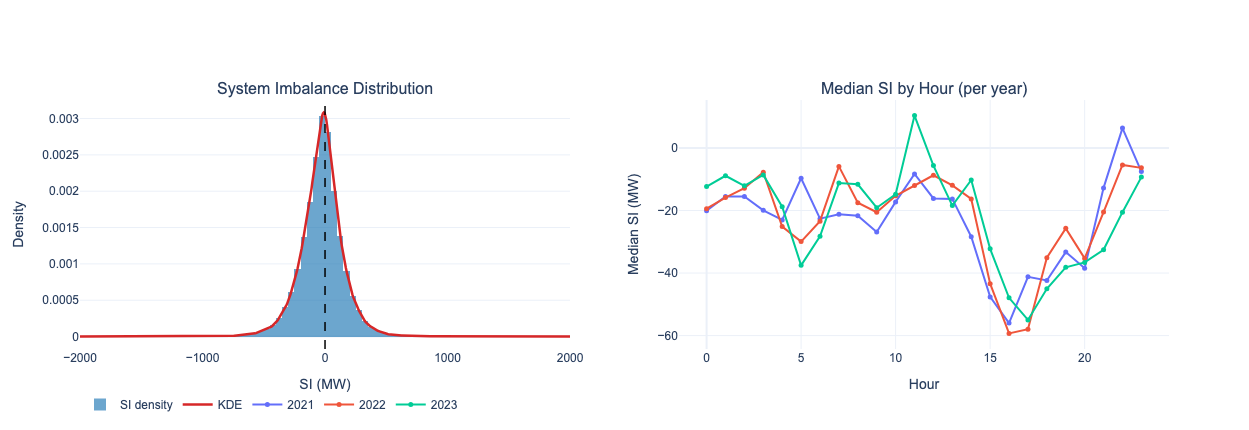

In [38]:
# 2.7 — System Imbalance distribution + hourly profile by year
_TITLE_IMB_SI = "System Imbalance (SI) — Distribution and Hourly Profile"

si_clip  = imb.si.clip(-2000, 2000)
kde_si_x = np.linspace(-2000, 2000, 600)
kde_si_y = gaussian_kde(si_clip.dropna())(kde_si_x)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["System Imbalance Distribution", "Median SI by Hour (per year)"],
)
fig.add_trace(go.Histogram(
    x=si_clip, nbinsx=120,
    marker_color=C_BLUE, opacity=0.65,
    histnorm="probability density", name="SI density",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=kde_si_x, y=kde_si_y, mode="lines",
    line=dict(color=C_RED, width=2.5), name="KDE",
), row=1, col=1)
fig.add_vline(x=0, line=dict(color="black", dash="dash", width=1.5))

for k, yr in enumerate(sorted(imb.year.unique())):
    si_hr = imb[imb.year == yr].groupby("hour")["si"].median()
    fig.add_trace(go.Scatter(
        x=si_hr.index, y=si_hr.values, mode="lines+markers",
        name=str(yr), line=dict(color=px.colors.qualitative.Plotly[k], width=2),
        marker=dict(size=5),
    ), row=1, col=2)

fig.update_layout(
    template=TEMPLATE, font_family=FONT,
    height=430, legend=dict(orientation="h", y=-0.16),
)
fig.update_xaxes(title_text="SI (MW)",        row=1, col=1)
fig.update_yaxes(title_text="Density",        row=1, col=1)
fig.update_xaxes(title_text="Hour",           row=1, col=2)
fig.update_yaxes(title_text="Median SI (MW)", row=1, col=2)
save(fig, "imb_si_distribution.png", title=_TITLE_IMB_SI, h=450)
fig.show()

---
## 3 — Joint Analysis <a id='joint'></a>

Saved → eda_figures/joint_dam_vs_imb_scatter.png


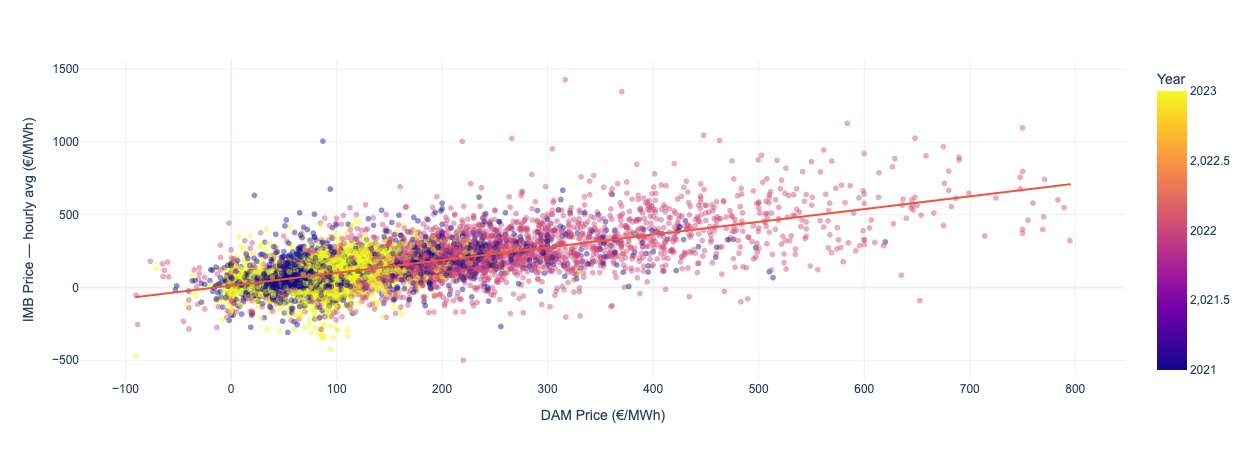

In [17]:
# 3.1 — DAM vs IMB price (hourly average of 15-min IMB)
_TITLE_JOINT = "DAM vs IMB Price (hourly, sample n=8,000)"

imb_hourly = (
    imb.set_index("timestamp")["pos_ip"]
    .resample("1h").mean()
    .reset_index()
    .rename(columns={"timestamp": "Date", "pos_ip": "imb_price"})
)
joint = dam.merge(imb_hourly, on="Date", how="inner")
sample = joint.sample(min(8000, len(joint)), random_state=42)

fig = px.scatter(
    sample, x="Price", y="imb_price",
    color="year",
    color_continuous_scale=px.colors.sequential.Plasma,
    opacity=0.45,
    labels={
        "Price":     "DAM Price (€/MWh)",
        "imb_price": "IMB Price — hourly avg (€/MWh)",
        "year":      "Year",
    },
    template=TEMPLATE,
    trendline="ols",
)
fig.update_layout(font_family=FONT, height=460)
save(fig, "joint_dam_vs_imb_scatter.png", title=_TITLE_JOINT, h=480)
fig.show()

Saved → eda_figures/extreme_events_by_year.png


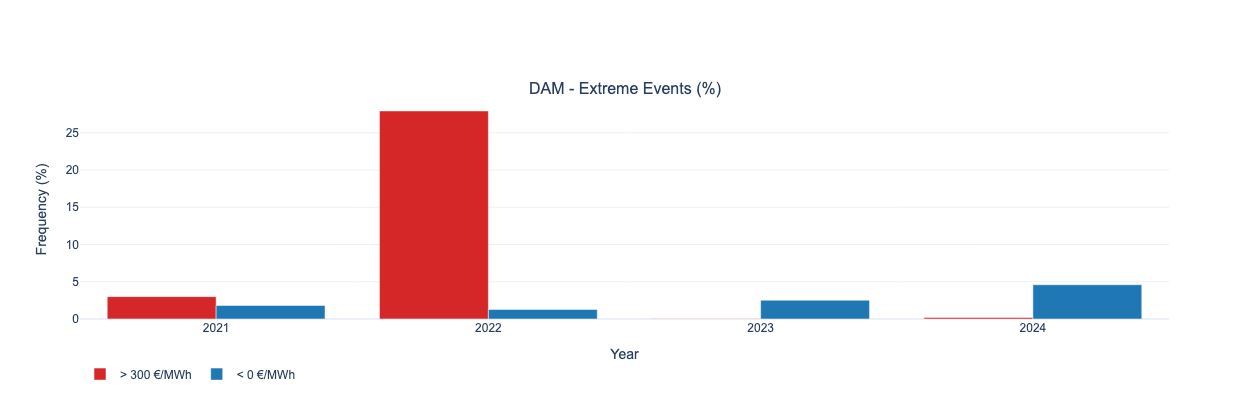

In [44]:
# 3.2 — Extreme event frequency by year
_TITLE_EXT = "Extreme Price Events by Year (% of observations)"

dam_ext = dam.groupby("year")["Price"].apply(
    lambda s: pd.Series({
        "> 300 €/MWh": (s > 300).mean() * 100,
        "< 0 €/MWh":   (s < 0).mean()   * 100,
    })
).unstack()

# imb_ext = imb.groupby("year")["pos_ip"].apply(
#     lambda s: pd.Series({
#         "> 500 €/MWh":  (s > 500).mean()  * 100,
#         "< -100 €/MWh": (s < -100).mean() * 100,
#     })
# ).unstack()

fig = make_subplots(
    rows=1, cols=1,
    subplot_titles=["DAM - Extreme Events (%)"]#, "IMB - Extreme Events (%)"],
)
for col, color in zip(dam_ext.columns, [C_RED, C_BLUE]):
    fig.add_trace(go.Bar(
        x=dam_ext.index.astype(str), y=dam_ext[col],
        name=col, marker_color=color,
    ), row=1, col=1)
# for col, color in zip(imb_ext.columns, [C_RED, C_BLUE]):
#     fig.add_trace(go.Bar(
#         x=imb_ext.index.astype(str), y=imb_ext[col],
#         name=col, marker_color=color, showlegend=False,
#     ), row=1, col=2)

fig.update_layout(
    template=TEMPLATE, font_family=FONT, barmode="group",
    height=400, legend=dict(orientation="h", y=-0.18),
)
fig.update_yaxes(title_text="Frequency (%)")
fig.update_xaxes(title_text="Year")
save(fig, "extreme_events_by_year.png", title=_TITLE_EXT, h=420)
fig.show()

In [19]:
# Figure registry and exported files
print("Figure registry (filename → title):")
for fname, title in FIGURE_REGISTRY.items():
    print(f"  {fname:<45s}  {title}")

print()
exported = sorted(f for f in os.listdir(EXPORT_DIR) if f.endswith(".png"))
print(f"PNG files in '{EXPORT_DIR}/' ({len(exported)}):")
for f in exported:
    size = os.path.getsize(os.path.join(EXPORT_DIR, f))
    print(f"  {f:<45s}  {size/1024:6.1f} KB")

Figure registry (filename → title):
  dam_hourly_heatmap.png                         DAM Price — Median by Hour × Day of Week
  dam_distribution.png                           DAM Price Distribution
  dam_correlation_matrix.png                     DAM — Pearson Correlation Matrix
  dam_ccf_covariates.png                         DAM Price — Cross-Correlation with Covariates (lag = hours)
  dam_acf_pacf.png                               DAM Price — ACF (168 lags) and PACF (72 lags)
  imb_qh_heatmap.png                             IMB Price — Median by Quarter-Hour × Day of Week
  imb_distribution.png                           IMB Price Distribution
  imb_correlation_matrix.png                     IMB — Pearson Correlation Matrix
  imb_ccf_covariates.png                         IMB Price — Cross-Correlation with Covariates (lag = ×15 min)
  imb_si_distribution.png                        System Imbalance (SI) — Distribution and Hourly Profile
  joint_dam_vs_imb_scatter.png                  